<a href="https://colab.research.google.com/github/francescopassante/GETMeshClassifier/blob/main/GET/src/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%rm -rf GETMeshClassifier/
!git clone https://github.com/francescopassante/GETMeshClassifier.git
%cd /content

Cloning into 'GETMeshClassifier'...
remote: Enumerating objects: 453, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 453 (delta 22), reused 132 (delta 19), pack-reused 314 (from 1)
Receiving objects: 100% (453/453), 678.85 KiB | 9.30 MiB/s, done.
Resolving deltas: 100% (147/147), done.
/content


In [3]:
MAX_NEIGH = 50

path = ""
if MAX_NEIGH == 200:
  # Download dataset with 200 neigbhors for each vertex
  !gdown 1e96CxX_JXAUGjYM1EOOtglIihpTFLN4J
  !unzip -q SHREC11_200NEIGH.zip
  path = "../../../SHREC11_200NEIGH/"
if MAX_NEIGH == 50:
  # Downloads dataset with 50 neighbors for each vertex
  !gdown 1TVBnGLPVMzu3udob2lZVbBKHH6J3tqN9
  !unzip -q SHREC11_50NEIGH.zip
  path = "../../../SHREC11_50NEIGH/"

Downloading...
From (original): https://drive.google.com/uc?id=1TVBnGLPVMzu3udob2lZVbBKHH6J3tqN9
From (redirected): https://drive.google.com/uc?id=1TVBnGLPVMzu3udob2lZVbBKHH6J3tqN9&confirm=t&uuid=68146102-4f41-4d47-82cc-596c41d0aeb7
To: /content/SHREC11_50NEIGH.zip
100% 701M/701M [00:08<00:00, 84.6MB/s]


In [4]:
%cd GETMeshClassifier/GET/src

/content/GETMeshClassifier/GET/src


In [6]:
import GET
import GEUtils
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

data = GET.load_data(
    mesh_directory=f"{path}processed/",
    labels_file=f"{path}classes.txt",
    train_percent=0.7,
    val_percent=0.15,
    device=device,
)

print(
    f"Train: {len(data['train_loader'])}  "
    f"Val: {len(data['val_loader'])}  "
    f"Test: {len(data['test_loader'])}"
)

Train: 418  Val: 89  Test: 91


In [7]:
model = GET.GETClassifier(N=9, channels=12, heads=2, out_classes=30).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=8)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model has {num_params} parameters")

Model has 9114 parameters


In [8]:
train_loss_hist, val_loss_hist, val_acc_hist = GET.train(
    model=model,
    dataloader=data["train_loader"],
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    epochs=70,
    accumulation_steps=16,
    val_loader=data["val_loader"],
    patience=25,
    test_loader=data["test_loader"],
)

Epoch 1: 100%|██████████| 418/418 [00:59<00:00,  7.03it/s]


Epoch 1: train_loss=3.3561  val_loss=3.2116  val_acc=9.0%
  -> New best val loss 3.2116, saved checkpoint_best.pth


Epoch 2: 100%|██████████| 418/418 [01:01<00:00,  6.77it/s]


Epoch 2: train_loss=2.9984  val_loss=2.9144  val_acc=9.0%
  -> New best val loss 2.9144, saved checkpoint_best.pth


Epoch 3: 100%|██████████| 418/418 [01:01<00:00,  6.77it/s]


...

Epoch 68: train_loss=0.4803  val_loss=1.0786  val_acc=70.8%
  -> No improvement (1/25)


Epoch 69: 100%|██████████| 418/418 [01:01<00:00,  6.80it/s]


Epoch 69: train_loss=0.4716  val_loss=1.1452  val_acc=66.3%
  -> No improvement (2/25)


Epoch 70: 100%|██████████| 418/418 [01:01<00:00,  6.80it/s]


Epoch 70: train_loss=0.5598  val_loss=1.0883  val_acc=69.7%
  -> No improvement (3/25)


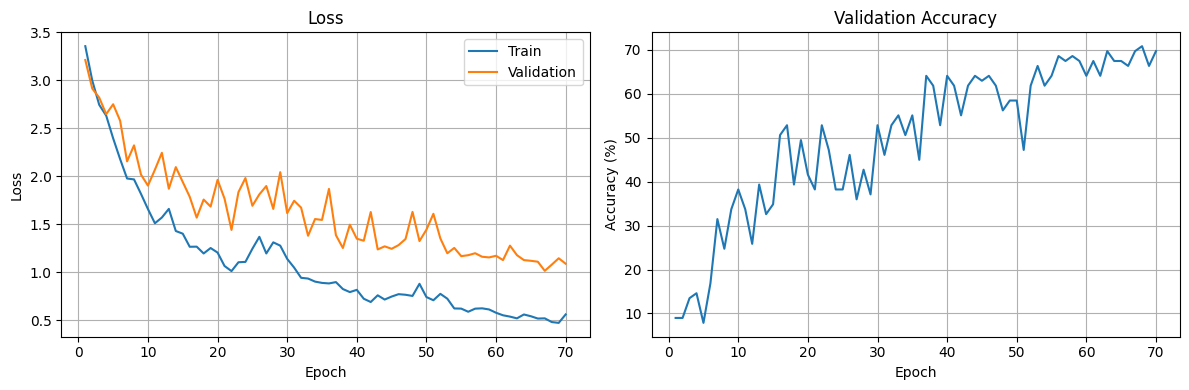

In [9]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_hist) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss_hist, label="Train")
ax1.plot(epochs, val_loss_hist, label="Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, val_acc_hist)
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
test_loss, test_acc = GET.validate(model=model, dataloader=data["test_loader"], criterion=criterion, device=device)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 78.02%


In [ ]:
def resume_from_best_checkpoint(checkpoint_path="checkpoint_best.pth"):
    data = GET.load_data_from_session(
        checkpoint_path=checkpoint_path,
        mesh_directory=f"{path}processed/",
        labels_file=f"{path}classes.txt",
        device=device,
    )
    cp = data["checkpoint"]

    model = GET.GETClassifier(N=9, channels=12, heads=2, out_classes=30).to(device)
    model.load_state_dict(cp["model_state_dict"])

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    optimizer.load_state_dict(cp["optimizer_state_dict"])

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=8)
    scheduler.load_state_dict(cp["scheduler_state_dict"])

    prev_hist = {
        "train_loss": cp.get("train_loss_hist", []),
        "val_loss":   cp.get("val_loss_hist", []),
        "val_acc":    cp.get("val_acc_hist", []),
    }

    print(f"Resumed from epoch {cp['epoch'] + 1}  (val_loss={cp['val_loss']:.4f})")
    return model, optimizer, scheduler, data, prev_hist, cp["epoch"] + 1


model, optimizer, scheduler, data, prev_hist, start_epoch = resume_from_best_checkpoint()

new_train, new_val, new_acc = GET.train(
    model=model,
    dataloader=data["train_loader"],
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    epochs=100,
    accumulation_steps=16,
    val_loader=data["val_loader"],
    patience=25,
    test_loader=data["test_loader"],
    start_epoch=start_epoch,
)

train_loss_hist = prev_hist["train_loss"] + new_train
val_loss_hist   = prev_hist["val_loss"]   + new_val
val_acc_hist    = prev_hist["val_acc"]    + new_acc